**Problem Statement:**

You are the Data Scientist at a telecom company “Leo” whose customers are churning out to its
competitors. You have to analyse the data of your company and find insights and stop your customers from
churning out to other telecom companies.

**Domain: Telecom**

**Domain Context:**

Customer churn, in simple terms means that the customer has stopped doing business with the company
and this is a common problem when it comes to telecom industries. To avoid this, companies use predictive
analysis to gauge the factors responsible for a customer to leave the company. These churn prediction
models help in finding out the customer base that are most likely to churn out.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
# import shutil

import tensorflow as tf
from sklearn.metrics import confusion_matrix

In [2]:
# shutil.unpack_archive('/content/AI-Project.zip')
# df = pd.read_excel('/content/customer-churn-data dictionary.xlsx', )

In [3]:
df = pd.read_csv('/content/customer_churn.csv')

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
# Total male employee
# df[df['gender']=='Male'].shape[0]
(df['gender']=='Male').sum()

np.int64(3555)

In [7]:
# Customers with DSL internet
df[df['InternetService'] == 'DSL'].shape[0]

2421

In [8]:
# Female senior citizens + Mailed check

fsc = df[
        (df['SeniorCitizen'] == 1)
        & (df['gender'] == 'Female')
        & (df['PaymentMethod'] == 'Mailed check')
    ]
fsc.head()
# fsc.shape[0]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
139,0390-DCFDQ,Female,1,Yes,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,70.45,70.45,Yes
176,2656-FMOKZ,Female,1,No,No,15,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.45,1145.7,Yes
267,3197-ARFOY,Female,1,No,No,19,Yes,No,Fiber optic,Yes,...,No,Yes,Yes,Yes,Month-to-month,Yes,Mailed check,105.00,2007.25,No
451,5760-WRAHC,Female,1,No,No,22,Yes,No,DSL,Yes,...,Yes,Yes,No,Yes,Month-to-month,Yes,Mailed check,69.75,1545.4,No
470,4933-IKULF,Female,1,No,No,17,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.65,330.6,No


In [9]:
# tenure < 10 OR total charges < 500
# convert totoal charges to numeric, NaN if non-numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(df['TotalCharges'].dtype, df['TotalCharges'].isnull().sum())
df_temp = df[
    (df['tenure'] < 10) |
    (df['TotalCharges'] < 500)
]
df_temp.head()

float64 11


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No


**Data Visualization**


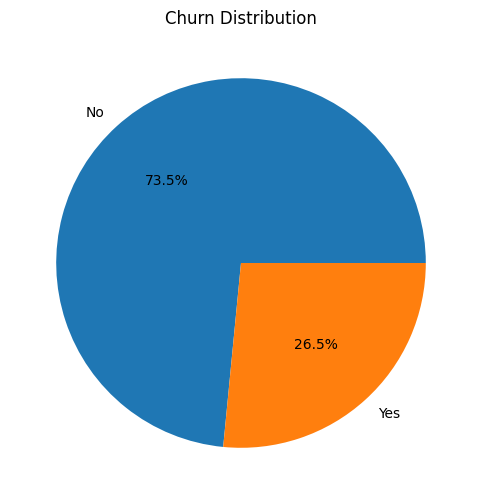

In [10]:
# Pie chart - churn distribution
df['Churn'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)
plt.title('Churn Distribution')
plt.ylabel('')
plt.show()


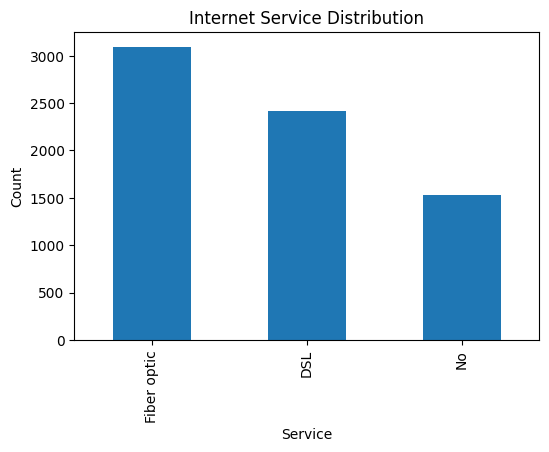

In [11]:
# Bar plot (Internet Service)
df['InternetService'].value_counts().plot(
    kind='bar',
    figsize=(6,4),
    )
plt.title('Internet Service Distribution')
plt.xlabel('Service')
plt.ylabel('Count')
plt.show()


**Model Building**


In [12]:
# Preprocessing (common for all models)

#label encoding for target variable
le = LabelEncoder()
df['Churn'] = le.fit_transform(df['Churn'])

df = df.dropna()

In [13]:
# model 1 (Only tenure)
X = df[['tenure']]
y = df['Churn']

# train test split
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [14]:
model1 = tf.keras.models.Sequential()

model1.add(tf.keras.layers.Dense(units=12, activation='relu', input_dim=1))
model1.add(tf.keras.layers.Dense(units=8, activation='relu'))
#,regularizer=tf.keras.regularizer.l2(0.02)

# output layer
model1.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))

model1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
history1 = model1.fit(
    x_train, y_train,
    epochs=500,
    validation_split=0.2,
    # verbose=0
)

Epoch 1/500
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7373 - loss: 0.5116 - val_accuracy: 0.7218 - val_loss: 0.5106
Epoch 2/500
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7373 - loss: 0.5111 - val_accuracy: 0.7218 - val_loss: 0.5112
Epoch 3/500
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7373 - loss: 0.5108 - val_accuracy: 0.7218 - val_loss: 0.5139
Epoch 4/500
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7373 - loss: 0.5114 - val_accuracy: 0.7218 - val_loss: 0.5123
Epoch 5/500
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7373 - loss: 0.5110 - val_accuracy: 0.7218 - val_loss: 0.5105
Epoch 6/500
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7373 - loss: 0.5112 - val_accuracy: 0.7218 - val_loss: 0.5105
Epoch 7/500
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7373 - loss: 0.5108 - val_accuracy: 0.7218 - val_loss: 0.5104
Epoch 8/500
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7373 - loss: 0.5114 - val_accu

In [21]:
# history1.history

In [22]:
#prediction and confusion matrix
y_pred = np.around(model1.predict(x_test), 0)
confusion_matrix(y_test, y_pred)

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


array([[980,  53],
       [292,  82]])

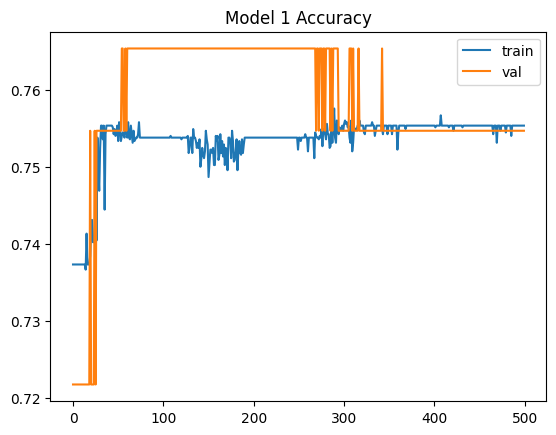

In [24]:
plt.plot(history1.history['accuracy'], label='train')
plt.plot(history1.history['val_accuracy'], label='val')
plt.legend()
plt.title("Model 1 Accuracy")
plt.show()

In [26]:
model2 = tf.keras.models.Sequential()

model2.add(tf.keras.layers.Dense(12, activation='relu', input_dim=1))
model2.add(tf.keras.layers.Dropout(0.3))

model2.add(tf.keras.layers.Dense(8, activation='relu'))
model2.add(tf.keras.layers.Dropout(0.2))

model2.add(tf.keras.layers.Dense(1, activation='sigmoid'))

model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [28]:
history2 = model2.fit(
    x_train, y_train,
    epochs=250,
    validation_split=0.2,
    verbose=0
)

In [30]:
y_pred2 = (model2.predict(x_test) > 0.5).astype(int)
print(confusion_matrix(y_test, y_pred2))

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[[980  53]
 [292  82]]


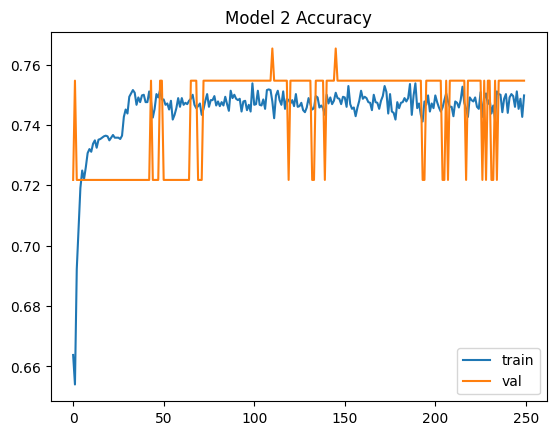

In [31]:
plt.plot(history2.history['accuracy'], label='train')
plt.plot(history2.history['val_accuracy'], label='val')
plt.legend()
plt.title("Model 2 Accuracy")
plt.show()

In [32]:
#model 3 - many features

X = df[['tenure', 'MonthlyCharges', 'TotalCharges']]
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [33]:
model3 = tf.keras.models.Sequential()

model3.add(tf.keras.layers.Dense(12, activation='relu', input_dim=3))
model3.add(tf.keras.layers.Dense(8, activation='relu'))
model3.add(tf.keras.layers.Dense(1, activation='sigmoid'))

model3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [34]:
history3 = model3.fit(
    X_train, y_train,
    epochs=250,
    validation_split=0.2,
    verbose=0
)

In [35]:
y_pred3 = (model3.predict(X_test) > 0.5).astype(int)
print(confusion_matrix(y_test, y_pred3))

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
[[952  81]
 [228 146]]


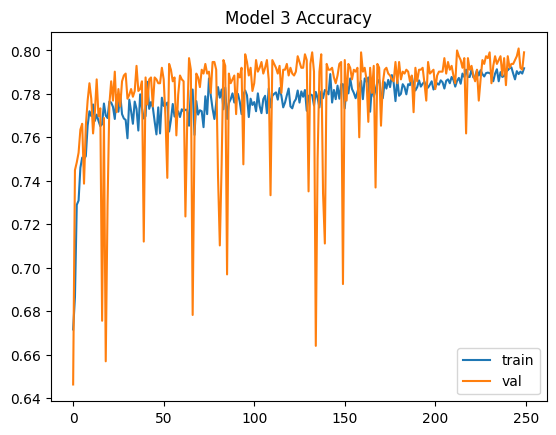

In [36]:
plt.plot(history3.history['accuracy'], label='train')
plt.plot(history3.history['val_accuracy'], label='val')
plt.legend()
plt.title("Model 3 Accuracy")
plt.show()

**Conclusion**

This project uses customer data to predict churn using deep learning. Data preprocessing and visualization help understand patterns, while neural networks learn relationships between customer attributes and churn behavior. Adding more features and regularization improves model performance significantly.